# Project Title - Customer Churn Analysis

## Problem Statement
Customer churn is a major challenge for businesses because losing existing customers can affect revenue and long-term growth.
The purpose of this project is to analyze customer data and identify the factors associated with customer churn.
The analysis will examine customer demographics, tenure, contract type, internet service, monthly charges, total charges, and other available features to understand the differences between customers who churn and those who remain.

## Objectives
- To understand the overall customer churn rate.
- To clean and prepare the customer data for analysis.
- To identify and handle missing values, duplicate records, and outliers.
- To analyze the distribution of numerical and categorical variables.
- To identify patterns and relationships between customer characteristics and churn.
- To determine which factors are more strongly associated with customer churn.
- To generate useful business insights that can help in customer retention strategies.
- To prepare the cleaned dataset for further SQL analysis and machine learning.

#### Import libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

#### Load Dataset

In [5]:
df = pd.read_csv("Customer_Churn_Analysis.csv")

## 1. Dataset Overview

#### Dataset Shape

In [6]:
df.shape

(1000, 11)

#### First 5 Rows

In [7]:
df.head()

,Unnamed: 0,CustomerID,Gender,Age,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
0,0,CUST_0001,Male,71,69,Yes,Fiber optic,Month-to-month,45.08,3110.52,No
1,1,CUST_0002,Female,80,71,No,DSL,Month-to-month,80.37,5706.27,Yes
2,2,CUST_0003,Male,34,24,No,NaN,One year,87.21,2093.04,No
3,3,CUST_0004,Male,26,11,Yes,NaN,One year,50.39,554.29,No
4,4,CUST_0005,Male,50,14,Yes,DSL,Month-to-month,104.51,1463.14,Yes


#### Last 5 Rows

In [8]:
df.tail()

,Unnamed: 0,CustomerID,Gender,Age,Tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
995,995,CUST_0996,Male,34,6,Yes,DSL,Two years,62.95,377.70,No
996,996,CUST_0997,Male,40,22,Yes,DSL,One year,107.75,2370.50,No
997,997,CUST_0998,Female,54,21,No,Fiber optic,Two years,69.56,1460.76,No
998,998,CUST_0999,Female,71,21,Yes,NaN,Two years,69.79,1465.59,No
999,999,CUST_1000,Male,33,28,Yes,Fiber optic,Two years,32.11,899.08,No


In [9]:
df.columns

Index(['Unnamed: 0', 'CustomerID', 'Gender', 'Age', 'Tenure', 'PhoneService',
       'InternetService', 'Contract', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='str')

In [10]:
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1000 non-null   int64  
 1   CustomerID       1000 non-null   str    
 2   Gender           1000 non-null   str    
 3   Age              1000 non-null   int64  
 4   Tenure           1000 non-null   int64  
 5   PhoneService     1000 non-null   str    
 6   InternetService  660 non-null    str    
 7   Contract         1000 non-null   str    
 8   MonthlyCharges   1000 non-null   float64
 9   TotalCharges     1000 non-null   float64
 10  Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 118.9 KB


In [11]:
#Statistical Summary
df.describe()

,Unnamed: 0,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,499.500000,49.09300,34.678000,68.510680,2339.684340
std,288.819436,18.16751,21.038796,29.073923,1808.263598
min,0.000000,18.00000,0.000000,18.000000,0.000000
25%,249.750000,34.00000,16.000000,43.740000,938.640000
50%,499.500000,50.00000,34.000000,69.020000,1900.125000
75%,749.250000,65.00000,52.250000,92.650000,3380.870000
max,999.000000,80.00000,72.000000,119.770000,8444.030000


## 2.Duplicate Value Analysis

#### A. Complete duplicate rows

In [12]:
df.duplicated().sum()

np.int64(0)

#### B. Duplicate Customer ID Check

In [13]:
df['CustomerID'].duplicated().sum()

np.int64(0)

No duplicate rows and Customer IDs were found.

## 3. Missing-value analysis

#### Number of missing values

In [14]:
df.isnull().sum()

Unnamed: 0           0
CustomerID           0
Gender               0
Age                  0
Tenure               0
PhoneService         0
InternetService    340
Contract             0
MonthlyCharges       0
TotalCharges         0
Churn                0
dtype: int64

In [15]:
#Percentage of missing values
(df.isnull().sum() / len(df) * 100).round(2)

Unnamed: 0          0.0
CustomerID          0.0
Gender              0.0
Age                 0.0
Tenure              0.0
PhoneService        0.0
InternetService    34.0
Contract            0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

#### InternetService analysis 

In [16]:
pd.crosstab(df['PhoneService'], df['InternetService'], dropna=False)

InternetService,DSL,Fiber optic,NaN
PhoneService,,,
No,198,143,161
Yes,155,164,179


340 missing Internet Service values are split across both PhoneService categories. So we cannot say that missing InternetService means "No internet".


In [17]:
df[df['InternetService'].isnull()]['PhoneService'].value_counts(dropna=False)

PhoneService
Yes    179
No     161
Name: count, dtype: int64

#### Replacing missing value with 'Unknown'.

In [18]:
df['InternetService'] = df['InternetService'].fillna('Unknown')

In [19]:
df['InternetService'].value_counts()

InternetService
DSL            353
Unknown        340
Fiber optic    307
Name: count, dtype: int64

In [20]:
#Verify
df.isnull().sum()

Unnamed: 0         0
CustomerID         0
Gender             0
Age                0
Tenure             0
PhoneService       0
InternetService    0
Contract           0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

## 4. Drop irrelevant index column

In [21]:
df.drop(columns=['Unnamed: 0'], inplace=True)

## 5. Numerical and categorical columns

In [22]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns
categorical_cols = df.select_dtypes(include=["str"]).columns
numerical_cols, categorical_cols 

(Index(['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str'),
 Index(['CustomerID', 'Gender', 'PhoneService', 'InternetService', 'Contract',
        'Churn'],
       dtype='str'))

In [23]:
df[categorical_cols].nunique()

CustomerID         1000
Gender                2
PhoneService          2
InternetService       3
Contract              3
Churn                 2
dtype: int64

#### Numerical Distribution Overview

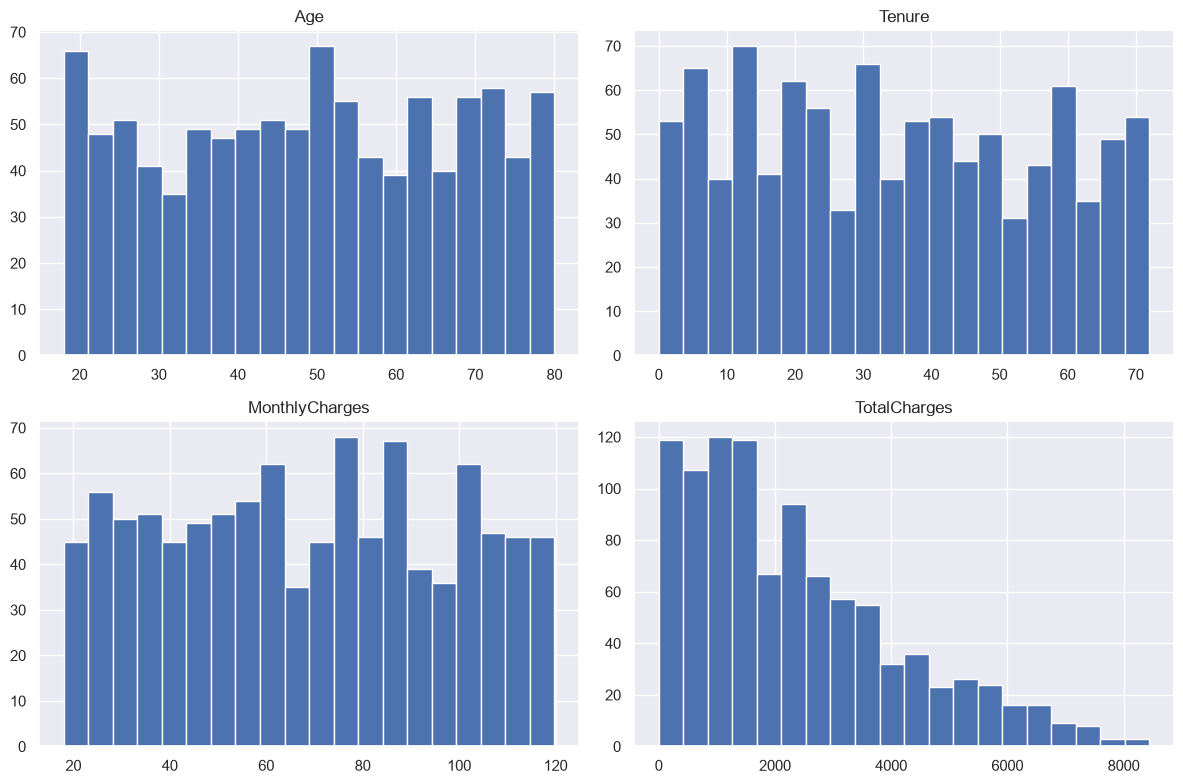

In [24]:
df[numerical_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## 6. Outlier analysis

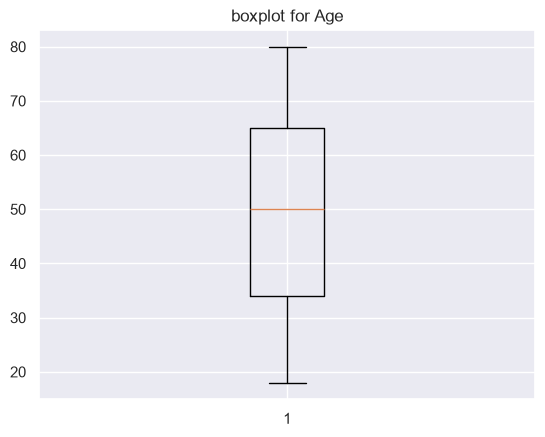

In [25]:
plt.boxplot(df["Age"])
plt.title("boxplot for Age")
plt.show() 

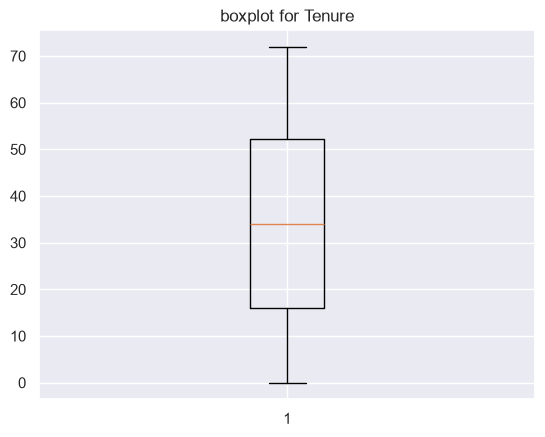

In [26]:
plt.boxplot(df["Tenure"])
plt.title("boxplot for Tenure")
plt.show() 

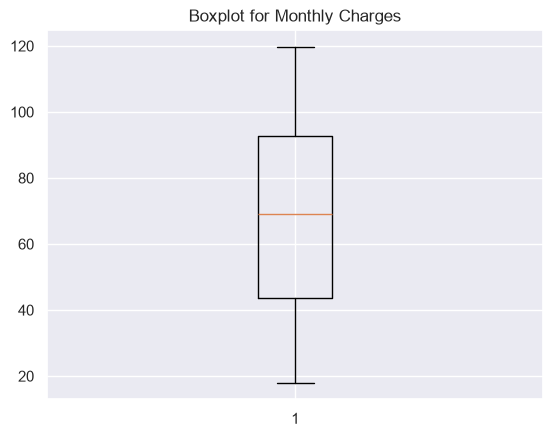

In [27]:
plt.boxplot(df["MonthlyCharges"])
plt.title("Boxplot for Monthly Charges")
plt.show() 

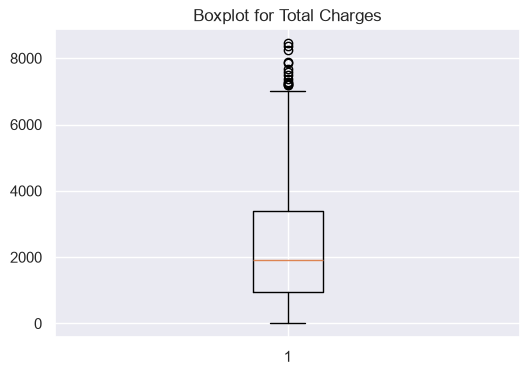

In [28]:
plt.figure(figsize=(6,4))
plt.boxplot(df["TotalCharges"])
plt.title("Boxplot for Total Charges")
plt.show() 

#### Outliers are present in TotalCharges.
#### Treated extreme values using capping instead of deleting records 

In [29]:
Q1 = df["TotalCharges"].quantile(0.25)
Q3 = df["TotalCharges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["TotalCharges"] = np.where(df["TotalCharges"] > upper_bound, upper_bound, df["TotalCharges"])
df["TotalCharges"] = np.where(df["TotalCharges"] < lower_bound, lower_bound, df["TotalCharges"])

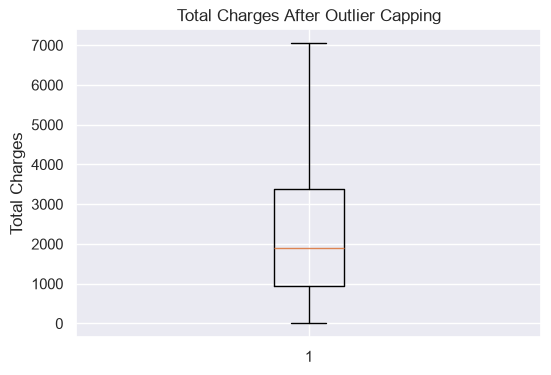

In [30]:
plt.figure(figsize=(6,4))
plt.boxplot(df["TotalCharges"])
plt.title("Total Charges After Outlier Capping")
plt.ylabel("Total Charges")
plt.show()

## 7. Skewness Analysis

In [31]:
skewness = df[numerical_cols].skew()
skewness

Age              -0.035875
Tenure            0.104941
MonthlyCharges    0.013618
TotalCharges      0.865821
dtype: float64

Age, Tenure and MonthlyCharges are approximately symmetric because their skewness values are close to zero. TotalCharges is positively skewed, indicating a longer tail toward higher values.

## 8. Univariate analysis

#### Numerical columns

#### A. Age Distribution

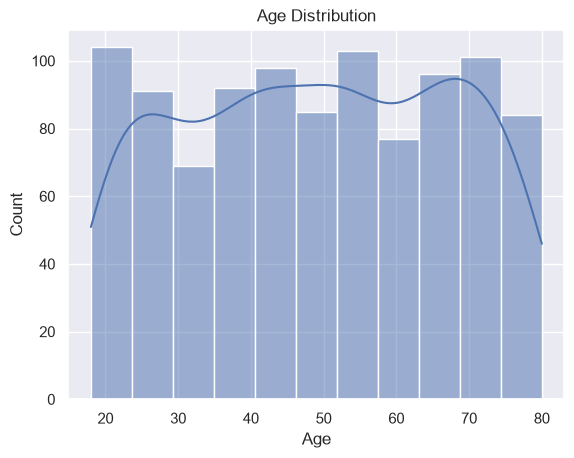

In [32]:
sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### Insights
- Customers are distributed across a wide age range of approximately 18 to 80 years.
- The distribution is fairly spread out, with no single age group dominating the dataset.
- There are no obvious extreme age values.
- The average customer age is around 49 years.

#### B. Tenure Distribution

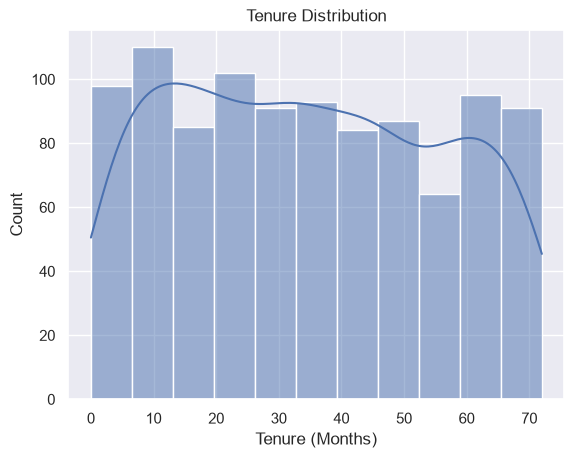

In [33]:
sns.histplot(df["Tenure"],kde=True)
plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()

### Insights
- Customer tenure ranges from 0 to 72 months.
- The dataset contains both new customers and long-term customers.
- Customers are distributed across different tenure periods.
- The average tenure is approximately 35 months.

#### C. Monthly Charges Distribution

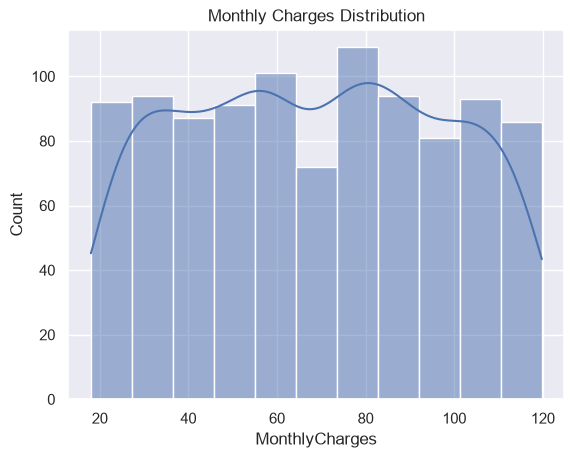

In [34]:
sns.histplot(df["MonthlyCharges"],kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("MonthlyCharges")
plt.ylabel("Count")
plt.show() 

### Insights
- Monthly charges range from approximately 18 to 120.
- The distribution is approximately symmetric.
- Most customers are spread fairly evenly across the monthly charge range.
- There is very little skewness in MonthlyCharges.

#### D. Total Charges Distribution

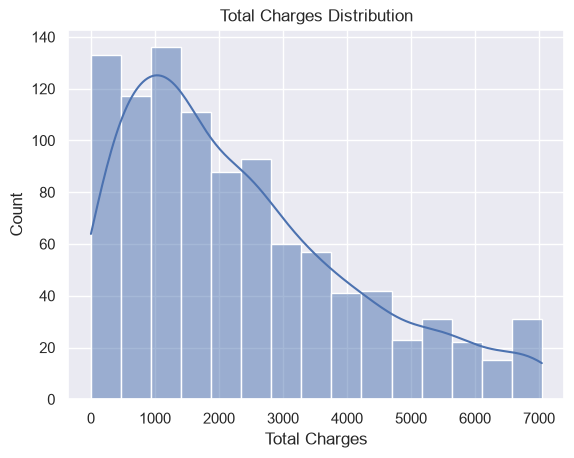

In [35]:
sns.histplot(df["TotalCharges"],kde=True)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Count")
plt.show() 

### Insights
- Total charges are positively/right skewed.
- Most customers have relatively lower to medium total charges.
- A smaller number of customers have much higher total charges.
- This right-skewness is expected because customers with longer tenure can accumulate higher total charges.

#### Categorical

#### A. Customer Churn Distribution

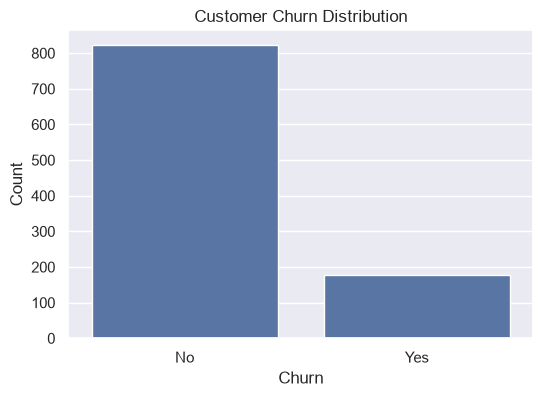

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Insights
- The majority of customers did not churn.
- The dataset is therefore dominated by customers who stayed.

#### B. Customer Distribution by Contract Type

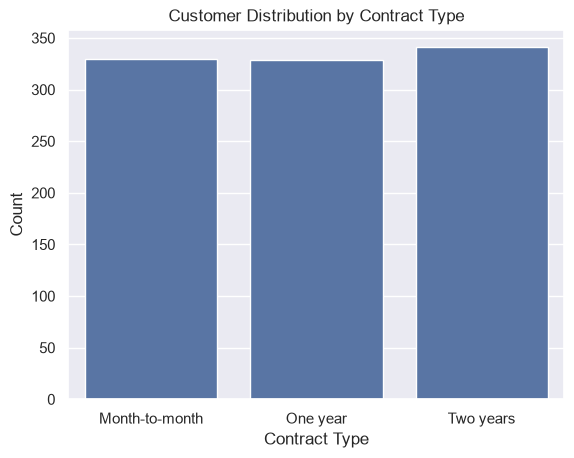

In [37]:
sns.countplot(data=df, x='Contract')
plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

### Insights
- Customers are relatively evenly distributed across the three contract types.
- Two-year contracts have the highest number of customers.
- Month-to-month and one-year contracts have very similar customer counts.
- There is no major imbalance in the number of customers across contract types.

## 9. Bivariate Analysis

#### A. Contract Type vs Churn

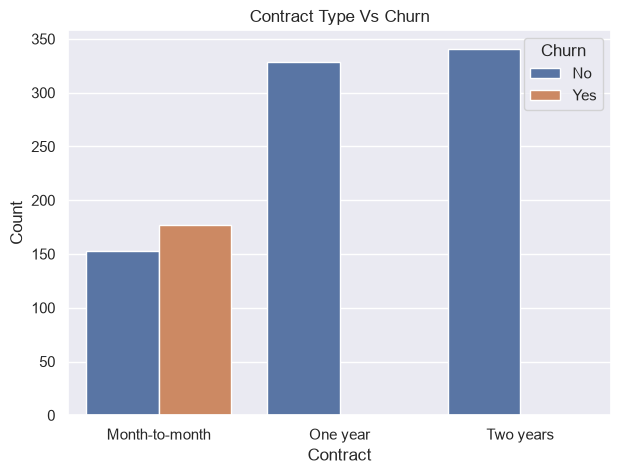

In [38]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x = "Contract",hue="Churn")
plt.title("Contract Type Vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show() 

### Insights
- All churned customers in this dataset belong to the month-to-month contract group.
- Month-to-month customers show a much stronger churn pattern.
- One-year and two-year contract customers have no churned customers in this dataset.
- This suggests that longer-term contracts are associated with stronger customer retention within this dataset.

#### B. Internet Service Type vs Churn

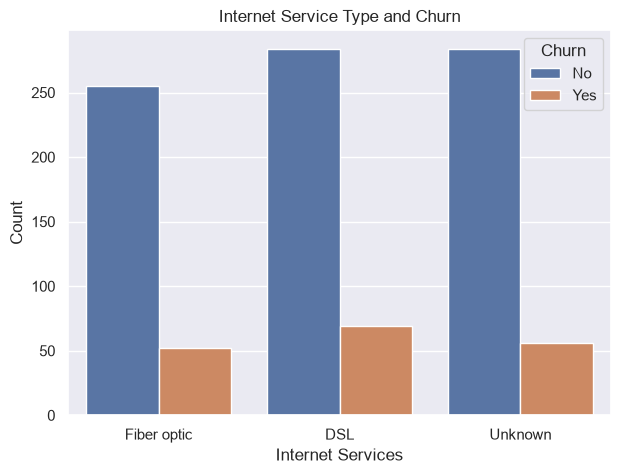

In [39]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x = "InternetService",hue="Churn")
plt.title("Internet Service Type and Churn")
plt.xlabel("Internet Services")
plt.ylabel("Count")
plt.show() 

### Insights
- DSL has the highest number of churned customers among the Internet Service categories.
- Fiber optic also shows a noticeable number of churned customers.
- The Unknown category shows some churned customers.
- Since the original missing InternetService values were replaced with Unknown, this category should not be interpreted as a specific service type.
- The graph shows differences in churn counts across Internet Service categories.

#### C. Tenure vs Churn

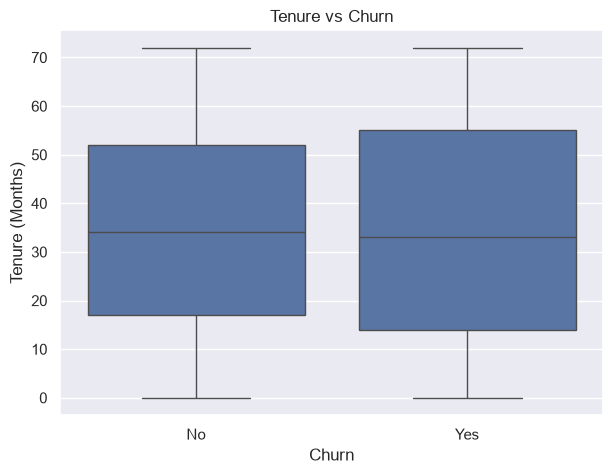

In [40]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Insights
- The tenure distributions of churned and non-churned customers are very similar.
- The median tenure is 34 months for stayed customers and 33 months for churned customers.
- There is no major difference in tenure between the two churn groups.
- Therefore, tenure does not show a strong visible difference between churn groups in this dataset.

#### D. Age vs Churn

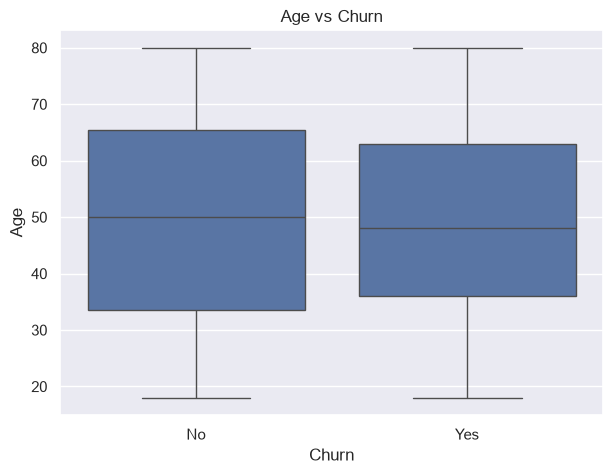

In [41]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='Age')
plt.title("Age vs Churn")
plt.xlabel("Churn")
plt.ylabel("Age")
plt.show()

### Insights
- The age distributions of churned and non-churned customers are broadly similar.
- The average age of churned customers is only slightly higher than that of non-churned customers.
- There is no strong visible difference in age between the two churn groups.
- Therefore, age does not show a strong relationship with churn in this dataset.

## Multivariate Analysis

#### A. Contract Type, Monthly Charges and Churn

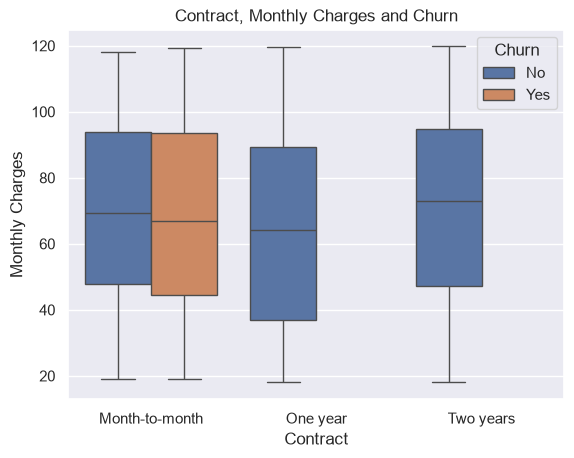

In [42]:
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn')
plt.title("Contract, Monthly Charges and Churn")
plt.xlabel("Contract")
plt.ylabel("Monthly Charges")
plt.show()

### Insights
- Monthly charges vary across different contract types.
- Month-to-month contracts contain both churned and non-churned customers.
- One-year and two-year contracts show no visible churned customers in this dataset.
- Within the month-to-month group, monthly charges show considerable overlap between churned and non-churned customers.
- Therefore, monthly charges alone do not clearly separate churned customers within the contract groups

#### B. Internet Service Type, Monthly Charges and Churn

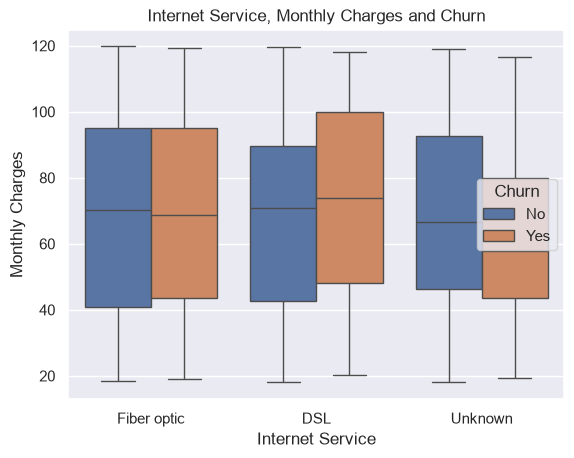

In [43]:
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', hue='Churn')
plt.title("Internet Service, Monthly Charges and Churn")
plt.xlabel("Internet Service")
plt.ylabel("Monthly Charges")
plt.show()

### Insights
- Monthly charges vary across Internet Service categories.
- DSL customers who churned show somewhat higher monthly charges than DSL customers who stayed.
- Fiber optic customers show considerable overlap between churned and non-churned groups.
- The Unknown category also shows variation in monthly charges between churn groups.
- Overall, monthly charges do not show a consistent separation between churned and non-churned customers across all Internet Service categories.

## Correlation Heatmap

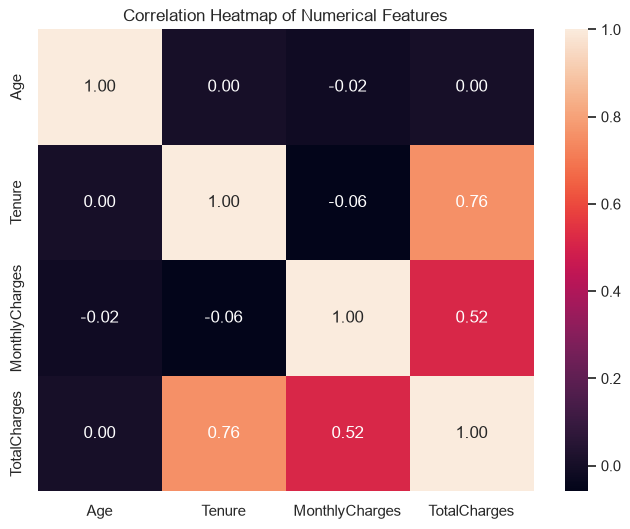

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Insights
- Tenure and TotalCharges have a strong positive correlation (0.76).
- MonthlyCharges and TotalCharges have a moderate positive correlation (0.52).
- Age has very weak relationships with the other numerical variables.
- Tenure and MonthlyCharges have a very weak negative correlation (-0.06).
- Overall, Tenure and TotalCharges have the strongest relationship among the numerical features.


### Save the cleaned dataset

In [46]:
df.to_csv("Customer_Churn_Cleaned.csv", index=False)

## Business Analysis Questions

##### Q1 Calculate the percentage of customers who have churned and the percentage who have stayed.

In [46]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)

Churn
No     82.3
Yes    17.7
Name: proportion, dtype: float64


##### Q2 Calculate the number and percentage of churned customers for each contract type.

In [47]:
churned_count = df[df["Churn"] == "Yes"]["Contract"].value_counts()
print(churned_count)

Contract
Month-to-month    177
Name: count, dtype: int64


In [48]:
#Percentage
churned_percentage = (pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100)
print(churned_percentage["Yes"].round(2))

Contract
Month-to-month    53.64
One year           0.00
Two years          0.00
Name: Yes, dtype: float64


##### Q3 Find the average monthly charges for churned and non-churned customers.

In [49]:
avg_monthly_charges = df.groupby("Churn")["MonthlyCharges"].mean()
print(avg_monthly_charges)

Churn
No     68.579271
Yes    68.191751
Name: MonthlyCharges, dtype: float64


##### Q4 Calculate the average tenure of churned and non-churned customers.

In [50]:
avg_tenure = df.groupby("Churn")["Tenure"].mean().round(2)
print(avg_tenure)

Churn
No     34.71
Yes    34.55
Name: Tenure, dtype: float64


##### Q5 Determine the number of churned customers for each Internet Service type, including the Unknown category.

In [51]:
churned_by_internet = df[df["Churn"] == "Yes"]["InternetService"].value_counts()
print(churned_by_internet)

InternetService
DSL            69
Unknown        56
Fiber optic    52
Name: count, dtype: int64


##### Q6 Find the top 10 customers with the highest monthly charges.

In [53]:
top_10_monthly = df[["CustomerID","MonthlyCharges"]].sort_values(by="MonthlyCharges",ascending=False).head(10)
print(top_10_monthly)


    CustomerID  MonthlyCharges
557  CUST_0558          119.77
860  CUST_0861          119.69
763  CUST_0764          119.65
476  CUST_0477          119.55
334  CUST_0335          119.24
739  CUST_0740          119.24
360  CUST_0361          119.18
772  CUST_0773          119.14
225  CUST_0226          119.01
15   CUST_0016          118.99


##### Q7 Find the top 10 customers with the highest total charges.

In [54]:
top_10_total = df[["CustomerID","TotalCharges"]].sort_values(by="TotalCharges",ascending=False).head(10)
print(top_10_total)

    CustomerID  TotalCharges
476  CUST_0477      7044.215
72   CUST_0073      7044.215
722  CUST_0723      7044.215
705  CUST_0706      7044.215
707  CUST_0708      7044.215
755  CUST_0756      7044.215
80   CUST_0081      7044.215
281  CUST_0282      7044.215
200  CUST_0201      7044.215
221  CUST_0222      7044.215


##### Q8 Create age groups such as 18–30, 31–45, 46–60, and 61–80, and calculate the number of customers and churn rate for each age group.

In [55]:
# Create age groups
bins = [17, 30, 45, 60, 80]
labels = ['18-30', '31-45', '46-60', '61-80']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

# Calculate customer count and churn rate
age_analysis = df.groupby('AgeGroup', observed=True).agg(
    Customer_Count=('CustomerID', 'count'),
    Churn_Rate=('Churn', lambda x: (x == 'Yes').mean() * 100)
)

age_analysis['Churn_Rate'] = age_analysis['Churn_Rate'].round(2)

print(age_analysis)

          Customer_Count  Churn_Rate
AgeGroup                            
18-30                206       12.62
31-45                231       22.08
46-60                240       20.42
61-80                323       15.79


##### Q9 Calculate the average monthly charges for each contract type.

In [56]:
avg_monthly_charges = df.groupby("Contract")["MonthlyCharges"].mean().round(2)
print(avg_monthly_charges)

Contract
Month-to-month    69.10
One year          65.39
Two years         70.95
Name: MonthlyCharges, dtype: float64


##### Q10 Calculate the number of customers using each Internet Service type.

In [57]:
internet_service_count = df['InternetService'].value_counts()

print(internet_service_count)

InternetService
DSL            353
Unknown        340
Fiber optic    307
Name: count, dtype: int64


# Key Insights
- Month-to-month contracts show the strongest churn pattern.
- Tenure distributions are broadly similar between churned and retained customers.
- Monthly charges show considerable overlap between churn groups.
- Internet Service categories show differences in churn patterns.
- Tenure and TotalCharges have a strong positive correlation.
- TotalCharges was treated using IQR-based capping.

# Conclusion

EDA helped identify important customer patterns associated with churn. The analysis indicates that contract type is an important factor in customer retention, while tenure and monthly charges alone do not clearly distinguish churned customers. These insights can help businesses identify high-risk customer segments and develop targeted customer retention strategies.